In [1]:
import pandas as pd
import psycopg2

outpath = r"C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports"

conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="",
    port=5432
)

cur = conn.cursor()

query = """
SELECT 
    user_session,
    product_id,
    price,
    event_type,
    event_time::TIMESTAMP as event_time,
    user_id,
    brand,
    category_code,
    category_id
FROM makeup_consumer_events.dec
WHERE event_type IN ('cart', 'purchase', 'remove_from_cart')
ORDER BY user_session, event_time
"""

cur.execute(query)
results = cur.fetchall()

conn.close()

# 转成 DataFrame
df = pd.DataFrame(results, columns=['user_session', 'product_id', 'price', 'event_type', 'event_time', 'user_id', 'brand', 'category_code', 'category_id'])
# 这里是只保留在第一次某次会话中，某个商品的某种动作，在这里的意思是只保留用户的第一次入购操作，其他的不管
df = df.drop_duplicates(subset=['user_session', 'product_id', 'event_type'], keep='first')

print(f"提取了 {len(df)} 条数据")
print(df.head(2))

提取了 1440319 条数据
                           user_session  product_id  price        event_type  \
0  00002b0e-d7f7-454e-8386-431c4021a9f6     5875358   2.05  remove_from_cart   
1  00002b0e-d7f7-454e-8386-431c4021a9f6     5891029   5.24              cart   

           event_time    user_id  brand category_code          category_id  
0 2019-12-18 06:48:39  531784651    NaN           NaN  2084144451428549153  
1 2019-12-18 06:50:18  531784651  irisk           NaN  1605161575889502297  


In [4]:
# 第二步：按 (user_session, product_id) 分组，合并信息
df_grouped = df.groupby(['user_session', 'product_id']).agg({
    'event_type': lambda x: list(x),
    'price': 'first',        
    'user_id': 'first', 
    'brand': 'first',
    'category_code': 'first',
    'category_id': 'first',
    'event_time': 'first'
}).reset_index()  # ← 关键！把索引变回普通列

def categorize_user(event_list):
    if 'purchase' in event_list:
        return 'A'
    elif 'remove_from_cart' in event_list:
        return 'C'
    else:
        return 'B'


# 第三步：标记 A/B
df_grouped['group_type'] = df_grouped['event_type'].apply(categorize_user)
   

# print(df_grouped.head(10))
print("\nA 组（购买）的行数:", len(df_grouped[df_grouped['group_type'] == 'A']))
print("B 组（被动流失）的行数:", len(df_grouped[df_grouped['group_type'] == 'B']))
print("C 组（被动流失）的行数:", len(df_grouped[df_grouped['group_type'] == 'C']))

df_grouped.to_csv(f"C:\\Users\\Administrator\\Desktop\\data_learn\\eCommerce_Events_History\\data\\interim\\03_user_behavior_groups3.csv", index=False)


A 组（购买）的行数: 211650
B 组（被动流失）的行数: 518495
C 组（被动流失）的行数: 424063


In [3]:
#  ===== AB两组的价格分布对比 =====
price_results_df = df_grouped[df_grouped['price'] >= 0]
price_stats = price_results_df.groupby('group_type')['price'].agg([
    'count',    # 商品数
    'mean',     # 平均价格
    'median',   # 中位数
    'std',      # 标准差
    'min',
    'max'
]).round(2)  # 计算 A/B 组的平均统计指标

print(price_stats)
# price_stats.to_csv(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\03_price_stats.csv')


def analyze_price_bins(df_grouped):
    # 常用操作：使用 pd.cut 进行分箱
    # 关键点：注意 bins 的边界值和 labels 的对应
    bins = [0, 5, 10, 20, 50, 100, 666]
    labels = ['0-5', '5-10', '10-20', '20-50', '50-100', '100+']

    df_price = df_grouped.copy()
    df_price['price_range'] = pd.cut(df_price['price'], bins=bins, labels=labels)

    
    # 计算交叉表（数量）
    price_stats = df_price.groupby(['price_range', 'group_type']).size().unstack(fill_value=0)
    
    price_pct = price_stats.div(price_stats.sum(axis=0), axis=1) * 100

    return price_pct

price_analysis = analyze_price_bins(df_grouped)
print("\n各价格段下 A/B/C 组的占比情况：")
print(price_analysis)


             count  mean  median    std  min     max
group_type                                          
A           211633  5.06    3.11   9.04  0.0  327.78
B           518495  5.31    3.33  10.26  0.0  327.78
C           424063  5.34    3.81  10.08  0.0  327.78

各价格段下 A/B/C 组的占比情况：
group_type           A          B          C
price_range                                 
0-5          69.882861  68.976008  68.379116
5-10         20.267178  21.226433  22.130254
10-20         7.376243   7.106321   6.951333
20-50         1.895587   2.009929   1.902939
50-100        0.444825   0.492582   0.456800
100+          0.133306   0.188727   0.179558


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8368\2734153995.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_stats = df_price.groupby(['price_range', 'group_type']).size().unstack(fill_value=0)


图表已成功保存至: C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\03_price_metrics_comparison.png


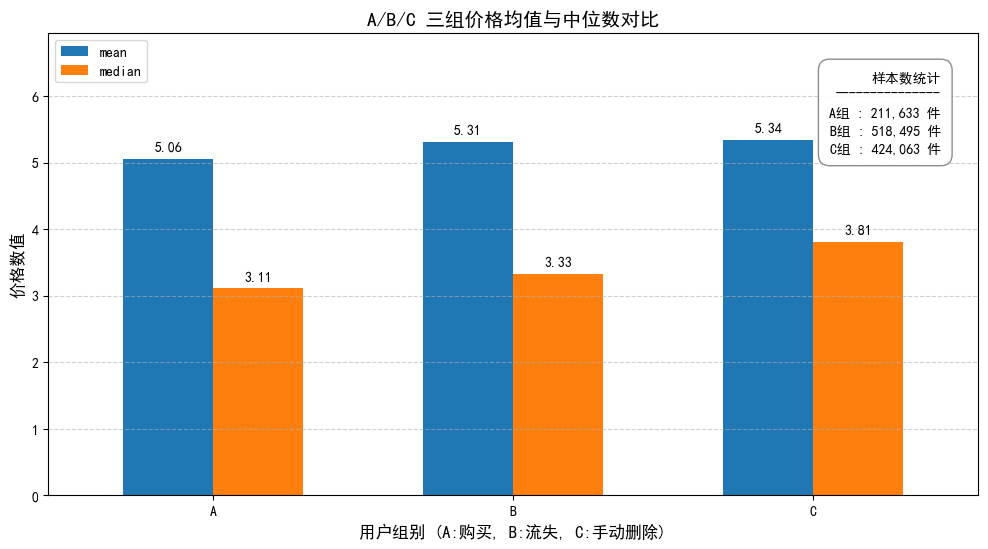

In [12]:
def price_plt(price_stats, outpath):
    import os
    import matplotlib.pyplot as plt
    
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False 

    # 只保留 mean 和 median 用于绘图
    plot_df = price_stats[['mean', 'median']]

    ax = plot_df.plot(kind='bar', figsize=(12, 6), width=0.6)

    plt.title('A/B/C 三组价格均值与中位数对比', fontsize=14)
    plt.xlabel('用户组别 (A:购买, B:流失, C:手动删除)', fontsize=12)
    plt.ylabel('价格数值', fontsize=12)
    plt.xticks(rotation=0) 
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # 扩大Y轴上限留出顶部空间 (取最大值乘以1.3)
    ax.set_ylim(0, plot_df.max().max() * 1.3)
    
    # 将图例移到左上角，避免和右侧文字打架
    ax.legend(loc='upper left')
    
    # 在柱状图上面标注具体金额
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')

    # 生成右上角的商品数量文本（优化排版：增加对齐和千分位分隔符）
    count_text = "样本数统计\n" + "-"*15 + "\n"
    lines = [f"{idx}组 : {int(row['count']):,} 件" for idx, row in price_stats.iterrows()]
    count_text += "\n".join(lines)
        
    # 微调右侧文本框位置 (0.96, 0.92)
    ax.text(0.96, 0.92, count_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='gray', alpha=0.9),
            fontsize=10, linespacing=1.5)

    filename = "03_price_metrics_comparison.png"
    save_path = os.path.join(outpath, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"图表已成功保存至: {save_path}")
    plt.show()

# 调用函数
price_plt(price_stats, outpath)


In [3]:
def analyze_time_gap(df_grouped, df):
    
    # ===== AB两组的时间区间对比 =====
    # 处理新的time_agg从df.groupby(['user_session', 'product_id'])提取最大最小时间，往新的time_agg成立一个新列'duration_hrs'得到时间差
    time_agg = df.groupby(['user_session', 'product_id'])['event_time'].agg(['min', 'max'])
    time_agg['duration_hrs'] = (time_agg['max'] - time_agg['min']).dt.total_seconds() / 3600


    # 将算好的时间差的time_agg使用左连接连上前面的df_grouped
    df_grouped_time = df_grouped.copy()
    df_grouped_time = df_grouped_time.loc[df_grouped_time['group_type'].isin(['A', 'C'])]  # 只保留 A/C 组
    df_grouped_time = df_grouped_time.merge(time_agg[['duration_hrs']], on=['user_session', 'product_id'], how='left')

    # 将time_range使用loc方法分箱分0-12，12-24，24-48，48-72，72-没买
    df_grouped_time['time_range'] = '72+'
    df_grouped_time.loc[df_grouped_time['duration_hrs'] <= 12, 'time_range'] = '0-12'
    df_grouped_time.loc[(df_grouped_time['duration_hrs'] > 12) & (df_grouped_time['duration_hrs'] <= 24), 'time_range'] = '12-24'
    df_grouped_time.loc[(df_grouped_time['duration_hrs'] > 24) & (df_grouped_time['duration_hrs'] <= 48), 'time_range'] = '24-48h'
    df_grouped_time.loc[(df_grouped_time['duration_hrs'] > 48) & (df_grouped_time['duration_hrs'] <= 72), 'time_range'] = '48-72h'


        # 展示结果
    time_summary = df_grouped_time.groupby(['group_type', 'time_range']).size().unstack(fill_value=0)

    return time_summary

time_summary_gap = analyze_time_gap(df_grouped, df)
print("A/C两组加购决策时长分布：")
# print(time_summary_gap)

def analyze_time_point(df_grouped, df):
    # 处理df，生成一张新的有'user_session', 'product_id', 'hours'列的新时间time_agg
    cart_time = df[df['event_type'] == 'cart'][['user_session', 'product_id', 'event_time']]
    cart_time['hours'] = df['event_time'].dt.hour

    # 使用新的time_agg与df_grounp左连接
    df_grouped_hour = df_grouped.copy()
    df_grouped_hour = df_grouped_hour.merge(cart_time[['user_session', 'product_id', 'hours']], on=['user_session', 'product_id'], how='left')

    # 统计一天不同时间的分布
    result_hour = df_grouped_hour.groupby(['group_type', 'hours']).size().unstack(fill_value=0)

    return result_hour
time_summary_point = analyze_time_point(df_grouped, df)
print("\nABC的一天不同时间的分布：")
print(time_summary_point)
#time_summary_point.to_csv(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\03_time_summary_point.csv')




A/C两组加购决策时长分布：

ABC的一天不同时间的分布：
hours       0.0   1.0   2.0   3.0    4.0    5.0    6.0    7.0    8.0    9.0   \
group_type                                                                     
A            911   899  1072  1262   1968   3220   4651   5325   6272   6440   
B           6042  5176  5772  7410  10641  16180  19465  22488  24720  26135   
C           1697  1279  1715  2114   3095   4735   5988   7358   8139   8535   

hours       ...   14.0   15.0   16.0   17.0   18.0   19.0   20.0   21.0  \
group_type  ...                                                           
A           ...   5599   5452   5451   5691   6261   6433   5914   4264   
B           ...  27349  26695  26761  28323  31959  34615  33482  25418   
C           ...   8417   8203   9126   9063  11143  10985  10641   8084   

hours        22.0  23.0  
group_type               
A            2305  1221  
B           15890  8659  
C            4581  2554  

[3 rows x 24 columns]


图表已成功保存至: C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\03_time_point_distribution1.png


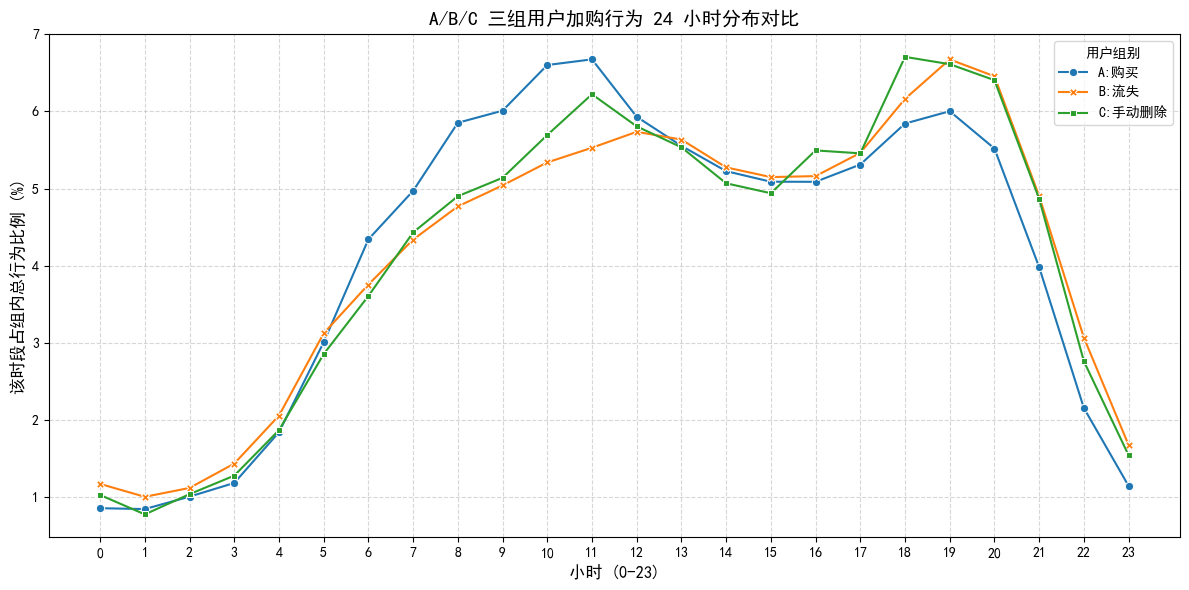

In [4]:
def timepoint_plot(time_summary_point, outpath):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os

    # 1. 解决中文乱码（Windows常用黑体）
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False 

    time_pct = time_summary_point.div(time_summary_point.sum(axis=1), axis=0) * 100

    # 【新增修改】在转置绘图前，直接修改 index 的名称，保证图例正确映射
    time_pct.index = time_pct.index.map({'A': 'A:购买', 'B': 'B:流失', 'C': 'C:手动删除'})

    plt.figure(figsize=(12, 6))
    
    # 3. 绘制折线图
    # time_pct.T 将 hours 变为行索引，方便 seaborn 读取为 X 轴
    sns.lineplot(data=time_pct.T, markers=True, dashes=False)

    # 4. 美化图表
    plt.title('A/B/C 三组用户加购行为 24 小时分布对比', fontsize=14)
    plt.xlabel('小时 (0-23)', fontsize=12)
    plt.ylabel('该时段占组内总行为比例 (%)', fontsize=12)
    plt.xticks(range(0, 24)) # 强制显示所有小时刻度
    plt.grid(True, linestyle='--', alpha=0.5)

    # 【删去硬编码的 labels】，只设置图例标题，Seaborn 将自动匹配刚刚修改过的类名
    plt.legend(title='用户组别')
    
    plt.tight_layout()
# .

    file_name = "03_time_point_distribution1.png"
    save_path = os.path.join(outpath, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已成功保存至: {save_path}")

    plt.show()

# 调用绘图
timepoint_plot(time_summary_point, outpath)



In [ ]:
# 价格和时间点分析

# 从前面的分析可以知道在时间点方面，16到4点流失多，尤其是19到23，可以从前面的函数analyze_time_point得到带prices和hours列的df_grouped_hour（好像），我觉得可以看看在这个时间段流失商品的价格分布

# STEP 2: 维度 1 - 时间切片 (打标)新建一列 'time_period'，IF hours 在 19 到 23 之间，则标记为 '高流失时段 (19-23)', 否则标记为 '常规时段'

# 这里只需要把df_grouped_hour的价格段列price_range补上

# 这里是使用groupby(['hours','price_range' , 'time_period])看看结果吗,

# STEP 5: 归一化 (计算占比)

# 结果